Persistence Length Data from Simulation trajcetory

In [ ]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
import csv

# ---------- Helper functions ----------

def apply_pbc(positions, box):
    Lx, Ly, Lz, xy, xz, yz = box
    box_lengths = np.array([Lx, Ly, Lz])
    positions = positions.copy()
    for dim in range(3):
        positions[:, dim] -= np.rint(positions[:, dim] / box_lengths[dim]) * box_lengths[dim]
    return positions

def residue_com_positions(positions, sequence):
    res_positions = []
    idx = 0
    for aa in sequence:
        if aa == 'G':
            indices = [idx, idx+1, idx+2]
            idx += 3
        else:
            indices = [idx, idx+1, idx+2, idx+3]
            idx += 4
        com = np.mean(positions[indices], axis=0)
        res_positions.append(com)
    return np.array(res_positions)

def tangent_vectors(positions):
    bonds = positions[1:] - positions[:-1]
    norms = np.linalg.norm(bonds, axis=1, keepdims=True)
    tangents = bonds / norms
    return tangents, norms.squeeze()

def tangent_correlation(tangents):
    n = len(tangents)
    C_s = []
    for s in range(1, n):
        dots = np.sum(tangents[:-s] * tangents[s:], axis=1)
        C_s.append(np.mean(dots))
    return np.array(C_s)

def exponential_fit(x, a, lp):
    return a * np.exp(-x / lp)

# ---------- Trajectory sets ----------

sets = [
    {
        "name": "Full_length",
        "base_path": "/home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162",
        "sequence": "MGLFDRLGRVVRANLNDLVSKAEDPEKVLEQAVIDMQEDLVQLRQAVARTIAEEKRTEQRLNQDTQEAKKWEDRAKLALTNGEENLAREALARKKSLTDTAAAYQTQLAQQRTMSENLRRNLAALEAKISEAKTKKNMLQARAKAAKANAELQQTLGGLGTSSATSAFERMENKVLDMEATSQAAGELAGFGIENQFAQLEASSGVEDELAALKASMAGGALPGTSAATPQLEAAPVDSSVPANNASQDDAVIDQELDDLRRRLNNL"
    },
    {
        "name": "H0_H3",
        "base_path": "/home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/3de12d848c06a70b5668c64369550562",
        "sequence": "MGLFDRLGRVVRANLNDLVSKAEDPEKVLEQAVIDMQEDLVQLRQAVARTIAEEKRTEQRLNQDTQEAKKWEDRAKLALTNGEENLAREALARKKSLTDTAAAYQTQLAQQRTMSENLRRNLAALEAKISEAKTKKNMLQARAKAAKANAELQQTL"
    },
    {
        "name": "H4_H6",
        "base_path": "/home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/7fd5f713b9bd4167bafd3d2d9378bc51",
        "sequence": "GGLGTSSATSAFERMENKVLDMEATSQAAGELAGFGIENQFAQLEASSGVEDELAALKASMAGGALPGTSAATPQLEAAPVDSSVPANNASQDDAVIDQELDDLRRRLNNL"
    }
]

num_chains = 64
bias_values = np.linspace(0.75, 1.0, 12)

# ============================
#       MAIN PROCESSING
# ============================

for s in sets:
    print(f"\n=== Processing set: {s['name']} ===")
    output_dir = os.path.join(os.getcwd(), s['name'])
    os.makedirs(output_dir, exist_ok=True)

    # Lists for saving results (residue + Å)
    biases_list = []
    lp_mean_residues_list = []
    lp_std_residues_list = []
    lp_mean_angstrom_list = []
    lp_std_angstrom_list = []

    for bias in bias_values:
        print(f"\nProcessing bias {bias:.2f} ...")

        csv_filename = os.path.join(output_dir, f"persistence_length_bias_{bias:.2f}.csv")
        pdf_filename = os.path.join(output_dir, f"tangent_correlation_bias_{bias:.2f}.pdf")

        # Skip if already done
        if os.path.isfile(csv_filename) and os.path.isfile(pdf_filename):
            print(f"Outputs for bias {bias:.2f} already exist. Skipping.")
            continue

        # Correct GSD filename handling
        trajectory_name = (
            f"trajectory_bias_{bias}.gsd" if bias in [0.75, 1.0]
            else f"trajectory_bias_{bias:.16f}.gsd"
        )
        trajectory_file = os.path.join(s['base_path'], trajectory_name)

        if not os.path.isfile(trajectory_file):
            print(f"File {trajectory_file} not found. Skipping.")
            continue

        traj = gsd.hoomd.open(trajectory_file, 'r')
        frames = traj[10000:20000]

        all_C_s = []
        all_arclengths = []
        lp_chains_residues = []

        for fr in frames:
            positions = apply_pbc(fr.particles.position, fr.configuration.box)
            num_particles_per_chain = len(positions) // num_chains

            for c in range(num_chains):
                start = c * num_particles_per_chain
                end = (c + 1) * num_particles_per_chain
                chain_positions = residue_com_positions(positions[start:end], s['sequence'])
                tangents, bond_lengths = tangent_vectors(chain_positions)

                arclength = np.cumsum(bond_lengths)
                C_s = tangent_correlation(tangents)

                all_C_s.append(C_s)
                all_arclengths.append(arclength)

                try:
                    popt, _ = curve_fit(exponential_fit, np.arange(1, len(C_s)+1), C_s, p0=(1.0, 10.0))
                    lp_chains_residues.append(popt[1])
                except:
                    continue

        if not lp_chains_residues:
            print(f"No chains processed for bias {bias:.2f}.")
            continue

        # === Compute persistence lengths ===
        lp_chains_residues = np.array(lp_chains_residues)
        lp_mean_residues = np.mean(lp_chains_residues)
        lp_std_residues = np.std(lp_chains_residues)

        # Bond length conversion to Å
        avg_bond_length = np.mean([np.mean(a[1:] - a[:-1]) for a in all_arclengths])
        lp_mean_angstrom = lp_mean_residues * avg_bond_length
        lp_std_angstrom = lp_std_residues * avg_bond_length

        print(f"Residue PL = {lp_mean_residues:.2f} ± {lp_std_residues:.2f}")
        print(f"Å PL = {lp_mean_angstrom:.2f} ± {lp_std_angstrom:.2f} Å")

        # === Store results ===
        biases_list.append(bias)
        lp_mean_residues_list.append(lp_mean_residues)
        lp_std_residues_list.append(lp_std_residues)
        lp_mean_angstrom_list.append(lp_mean_angstrom)
        lp_std_angstrom_list.append(lp_std_angstrom)

        # --- Compute average tangent correlation ---
        min_len = min(len(c) for c in all_C_s)
        avg_C_s = np.mean([c[:min_len] for c in all_C_s], axis=0)
        avg_arclength = np.mean([a[:min_len] for a in all_arclengths], axis=0)

        # --- Save correlation CSV ---
        with open(csv_filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Arclength (Å)', 'CosThetaCorrelation'])
            for x, y in zip(avg_arclength, avg_C_s):
                writer.writerow([x, y])

        # --- Plot tangent correlation ---
        popt_fit, _ = curve_fit(exponential_fit, np.arange(1, min_len+1), avg_C_s, p0=(1.0, 10.0))
        plt.figure(figsize=(8,6))
        plt.plot(avg_arclength, avg_C_s, 'o', label='Cos θ correlation')
        plt.plot(avg_arclength, exponential_fit(np.arange(1, min_len+1), *popt_fit), '-',
                 label=f'Fit: lp={lp_mean_angstrom:.2f} Å')
        plt.xlabel('Arclength separation |x-y| (Å)')
        plt.ylabel('⟨cos θ⟩')
        plt.title(f'Tangent Correlation (bias {bias:.2f})')
        plt.grid(True, linestyle='--')
        plt.legend()
        plt.tight_layout()
        plt.savefig(pdf_filename)
        plt.close()

    # ============================
    # Save summary CSV for this set
    # ============================

    summary_csv = os.path.join(output_dir, "persistence_length_vs_bias.csv")
    with open(summary_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'Bias',
            'PersistenceLengthMean_residues',
            'PersistenceLengthStd_residues',
            'PersistenceLengthMean_Angstrom',
            'PersistenceLengthStd_Angstrom'
        ])

        for b, r_mean, r_std, a_mean, a_std in zip(
            biases_list,
            lp_mean_residues_list,
            lp_std_residues_list,
            lp_mean_angstrom_list,
            lp_std_angstrom_list
        ):
            writer.writerow([b, r_mean, r_std, a_mean, a_std])

    print(f"\nSaved summary CSV → {summary_csv}")


Persistence Length Plot from above data

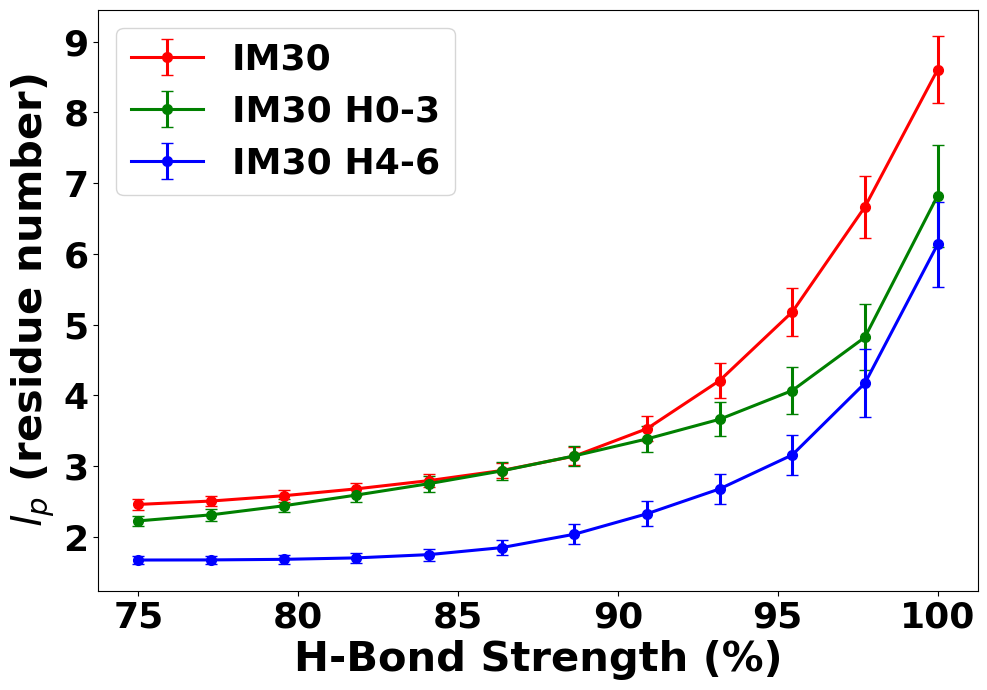

Figure saved to: /home/POLY/bhandarit/Desktop/chain_n_chain/persistance_length/persistence_length_residue_vs_hbond_strength.png


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Base directory
base_dir = "Code_simulation_analysis/analysis/structure_analysis_Figure_2_SI/Persistance_length/"

# Subfolders, labels, and colors
folders = {
    "Full_length": ("IM30", "red"),
    "H0_H3": ("IM30 H0-3", "green"),
    "H4_H6": ("IM30 H4-6", "blue")
}

plt.figure(figsize=(10, 7))

for folder, (label, color) in folders.items():
    file_path = os.path.join(base_dir, folder, "persistence_length_vs_bias.csv")
    df = pd.read_csv(file_path)

    # Convert Bias → H-Bond Strength (%)
    df["HbondStrength"] = df["Bias"] * 100

    # Divide STD by sqrt(12) to propagate SEM
    sem = df["PersistenceLengthStd_residues"] / np.sqrt(12)

    plt.errorbar(
        df["HbondStrength"],
        df["PersistenceLengthMean_residues"],
        yerr=sem,
        marker="o",
        color=color,
        linewidth=2.2,
        markersize=7,
        capsize=4,
        label=label
    )

# Labels + formatting
plt.xlabel("H-Bond Strength (%)", fontsize=30, fontweight="bold")
plt.ylabel(r"$l_p$ (residue number)", fontsize=30, fontweight="bold")
plt.xticks(fontsize=26, fontweight='bold')
plt.yticks(fontsize=26, fontweight='bold')

legend = plt.legend(fontsize=26, title_fontsize=26)
plt.setp(legend.get_title(), fontweight='bold')
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.tight_layout()

# ----- SAVE FIGURE -----
output_path = os.path.join(base_dir, "persistence_length_residue_vs_hbond_strength.png")
plt.savefig(output_path, dpi=600, bbox_inches='tight')

plt.show()
print(f"Figure saved to: {output_path}")
